In [1]:
!pip install ../.

Processing /Users/pgulley/Projects/mediacloud/PELT_tests/peltdetect
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for peltdetect: filename=peltdetect-0.1.0-py3-none-any.whl size=41739 sha256=aff690bca54bec1e67b0f0afe039bf17ba0830aec608c0b38bb7b70c8410b75c
  Stored in directory: /private/var/folders/s7/3jfk02ks6s7_7dnsnzw5300m0000gn/T/pip-ephem-wheel-cache-0sgxkwv4/wheels/97/f5/3d/4ea8b7cfa0c54f7f62d1255282104aee3843ac21fbc80e4685
Successfully built peltdetect
  Attempting uninstall: peltdetect
    Found existing installation: peltdetect 0.1.0
    Uninstalling peltdetect-0.1.0:
      Successfully uninstalled peltdetect-0.1.0


In [2]:
from pathlib import Path
import sys

# Make local package importable when running notebook directly.
# After flattening, the package lives at: peltdetect/peltdetect/
repo_root = Path.cwd().resolve().parent
pkg_path = repo_root
if str(pkg_path) not in sys.path:
    sys.path.insert(0, str(pkg_path))

from peltdetect import MCPelt
MCPelt

peltdetect.mc_pelt.MCPelt

In [6]:
import datetime as dt
import mediacloud.api
import pandas as pd
API_KEY = "#########"  # hard-coded for notebook demo
QUERY = "*"

START_DATE = dt.date(2024, 1, 1)
END_DATE = dt.date(2025, 3, 31)
search = mediacloud.api.SearchApi(API_KEY)


In [7]:
pelt_detector = MCPelt()

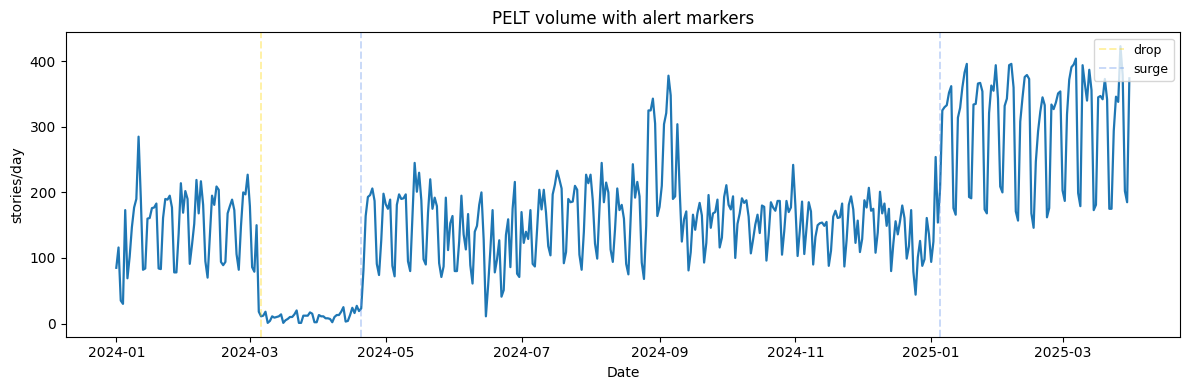

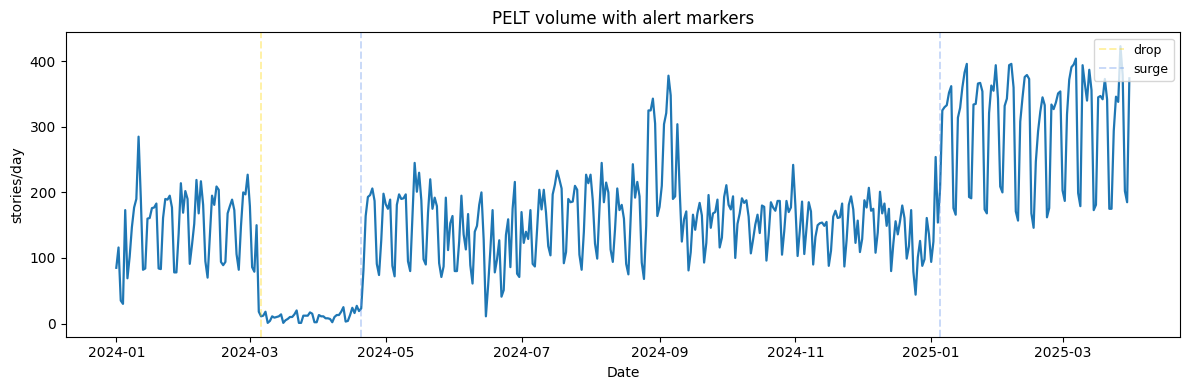

In [8]:
#What source to run it on- new york times in this case
SOURCE_ID = 1

raw = search.story_count_over_time(
    query=QUERY,
    start_date=START_DATE,
    end_date=END_DATE,
    source_ids=[SOURCE_ID],
)
series_df = pd.DataFrame(raw).rename(columns={"count": "volume"})
series_df["date"] = pd.to_datetime(series_df["date"]).dt.date
series_df = series_df[["date", "volume"]].sort_values("date").reset_index(drop=True)
series_df.head()

alerts = pelt_detector(series_df)

result = pelt_detector(series_df)
pelt_detector.chart_alerts(series_df, result["alerts"])